### __Introduction__

Once a model is trained, it is best to **separate the model from the training code** and use it to make predictions going forward. This ensures the model is lightweight and efficient to put into **production**.

We often do this by **'saving'** the model:

> **Saving a model entails storing its parameters and all information needed to make predictions.**

For example, in the case of a model represented as `y = ax + b`, we would save the `a` and `b` parameters and the fact that it is a linear model.

At this point in the course, you should be familiar with how to train, test, and measure the performance of various machine learning models on a given dataset. In this notebook we cover how to **save** your models into a portable format and **deploy** them in the wild.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [9]:
from styleplot import style_plot

In [2]:
from sklearn.datasets import load_diabetes
data = load_diabetes()

In [3]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [4]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['progression'] = pd.Series(data.target)

In [5]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


__Training the data__

In [6]:
# split data into X and y
y = df['progression']
X = df.drop('progression',axis=1)

# standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# get training and testing data 
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

__Model fitting__

In [7]:
# define the model 
model = LinearRegression()

# fit the model 
model.fit(X_train, y_train)

# get predictions on the test set 
y_pred = model.predict(X_test)

# calculate performance metrics
print("MSE:",mean_squared_error(y_test, y_pred))

MSE: 2900.1936284934814


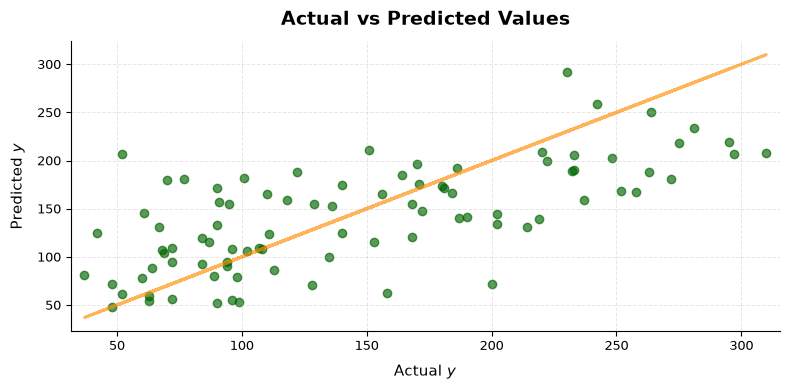

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(
    y_test, 
    y_pred, 
    color='#347989', 
    alpha =0.65
)

ax.plot(
    y_test, 
    y_test, 
    color="darkorange",
    linewidth=2,
    alpha=0.65
)

style_plot(
    ax,
    title="Actual vs Predicted Values",
    xlabel="Actual $y$",
    ylabel="Predicted $y$",
    grid=True
)

plt.tight_layout()
plt.show()

### 2. __Object serialisation__

Object serialisation is the **storing of variables** and **their values** as a **file**.

If we save a standard Python program (i.e. `.py` file), the program needs to be executed before variables can realise their values.

For example, think of a saved Jupyter Notebook file (`.ipynb`) where we have to **re-execute all program cells** before we can continue working on our program.

In the context of machine learning models, this means we have to **re-train our models** on the original train data before we can use them on other unseen data.

>Object serialisation allows us to store our variables and their state as a file, which upon loading can restore the variable and the value it had when we saved it.

This way, we can **save** our **sklearn models** along with **their optimal parameters** and **load** them later for reuse.

In this notebook, we will explore **`pickle`**, a common Python library for object serialisation.

### __Saving the model with Pickle__

Files saved using `pickle` are called ***pickles*** and the process of making them is referred to as ***pickling*** (we know, they took the metaphor quite far...).

Luckily for us, saving models using `pickle` follows a similar structure to that of creating or writing to a file in Python.

In [20]:
import pickle

model_save_path = "mlr_model.pkl"

# Save the trained model
with open(model_save_path, "wb") as file:
    pickle.dump(model, file)

__What each part means__
- __"wb"__ = write binary mode. Pickle saves objects in binary format.
- __pickle.dump(model, file)__ = saves your trained model into the file.
- __mlr_model.pkl__ = the file that will contain your trained model.

__You can then load it later__

In [21]:
with open("mlr_model.pkl", "rb") as _file:
    loaded_model = pickle.load(_file)

__Then use it for prediction__

In [23]:
y_pred = loaded_model.predict(X_test)

In [24]:
# calculate performance metrics
print('MSE:', mean_squared_error(y_test, y_pred))

MSE: 2900.1936284934814
